# Model fit assessment

In [91]:
import pandas as pd

df = pd.read_pickle('../data/calibration_results.pkl')

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1052/207101899.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


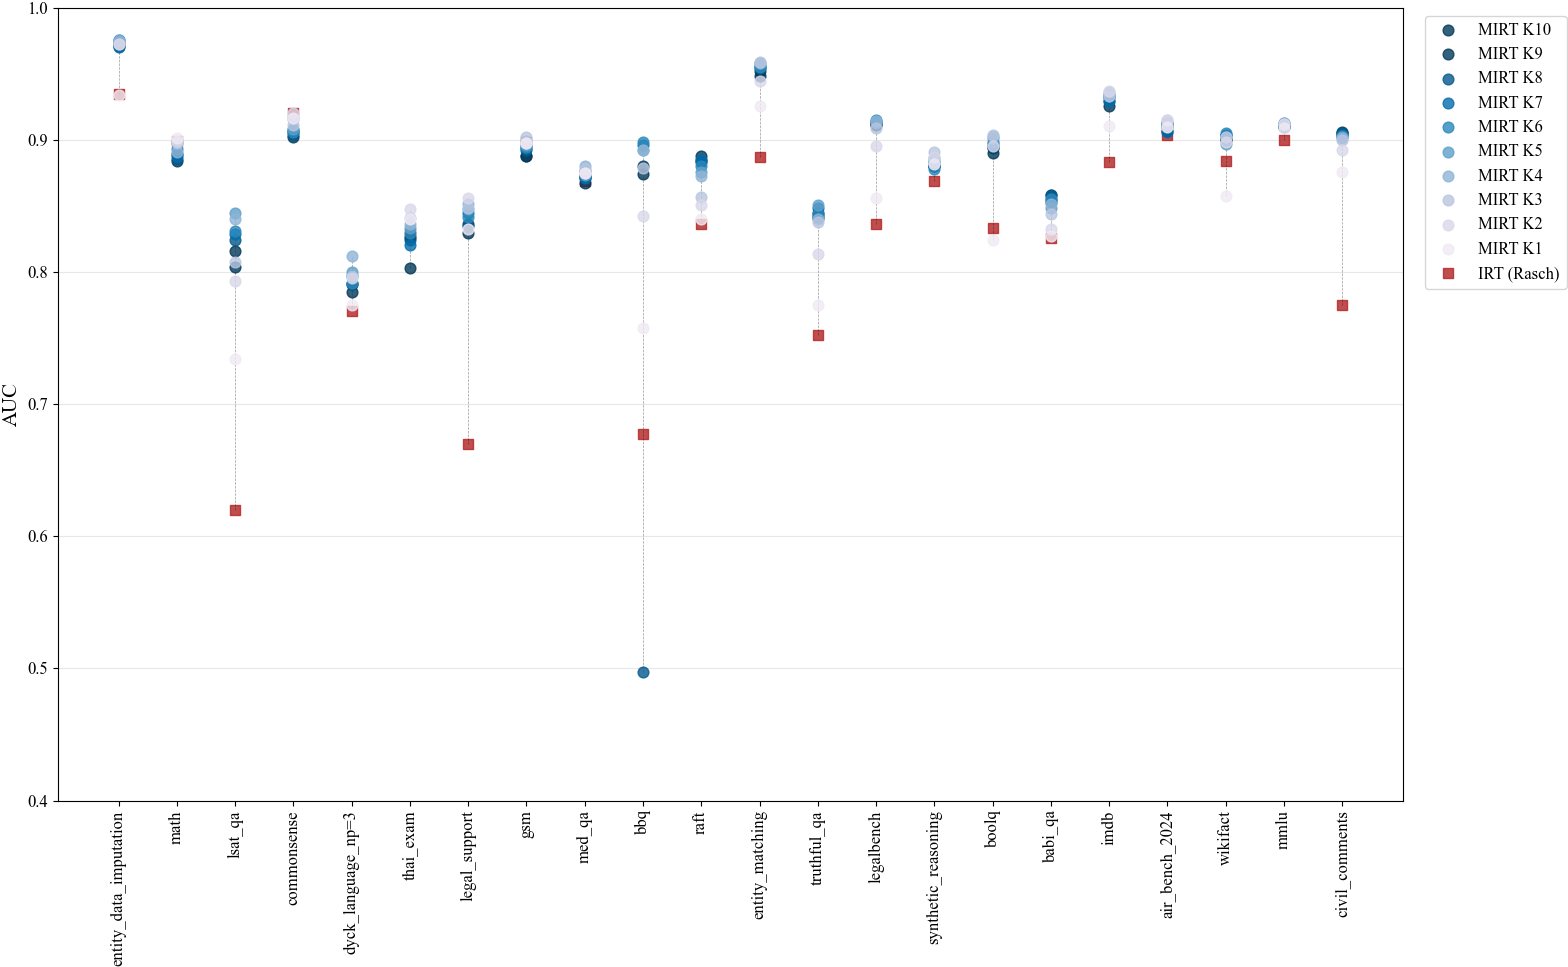

In [92]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..') 
import style

# Create the transposed dumbbell plot with k-factor colors, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))

# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df['k_factor'].unique())

# Create a grayscale colormap that reflects numerical order
colors = plt.get_cmap('PuBu')
# Use a subset of the colormap to avoid too light colors
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# Plot for each k-factor
for k_factor in reversed(k_factors):
	df_k = df[df['k_factor'] == k_factor]
	
	if len(df_k) == 0:
		continue
	
	# Get x positions for this k-factor's scenarios
	x_positions = [x_pos[scenario] for scenario in df_k['scenario']]
	
	# Plot the MIRT points
	ax.scatter(x_positions, df_k['mirt'], 
			  color=color_map[k_factor], s=60, 
			  label=f'MIRT K{k_factor}', 
			  marker='o', alpha=0.8, zorder=3)

# Plot IRT (Rasch) points - same for all k-factors
# Get one representative IRT value per scenario (they should be the same across k-factors)
df_irt = df.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between lowest and highest values for each scenario
for scenario in scenarios:
	df_scenario = df[df['scenario'] == scenario]
	if len(df_scenario) == 0:
		continue
	
	x = x_pos[scenario]
	
	# Get all values (both IRT and MIRT) for this scenario
	all_values = list(df_scenario['mirt']) + [df_scenario['irt'].iloc[0]]
	
	# Find min and max values
	min_val = min(all_values)
	max_val = max(all_values)
	
	# Draw line from lowest to highest value
	ax.plot([x, x], [min_val, max_val], 'k--', linewidth=0.5, alpha=0.4)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1052/1056642770.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


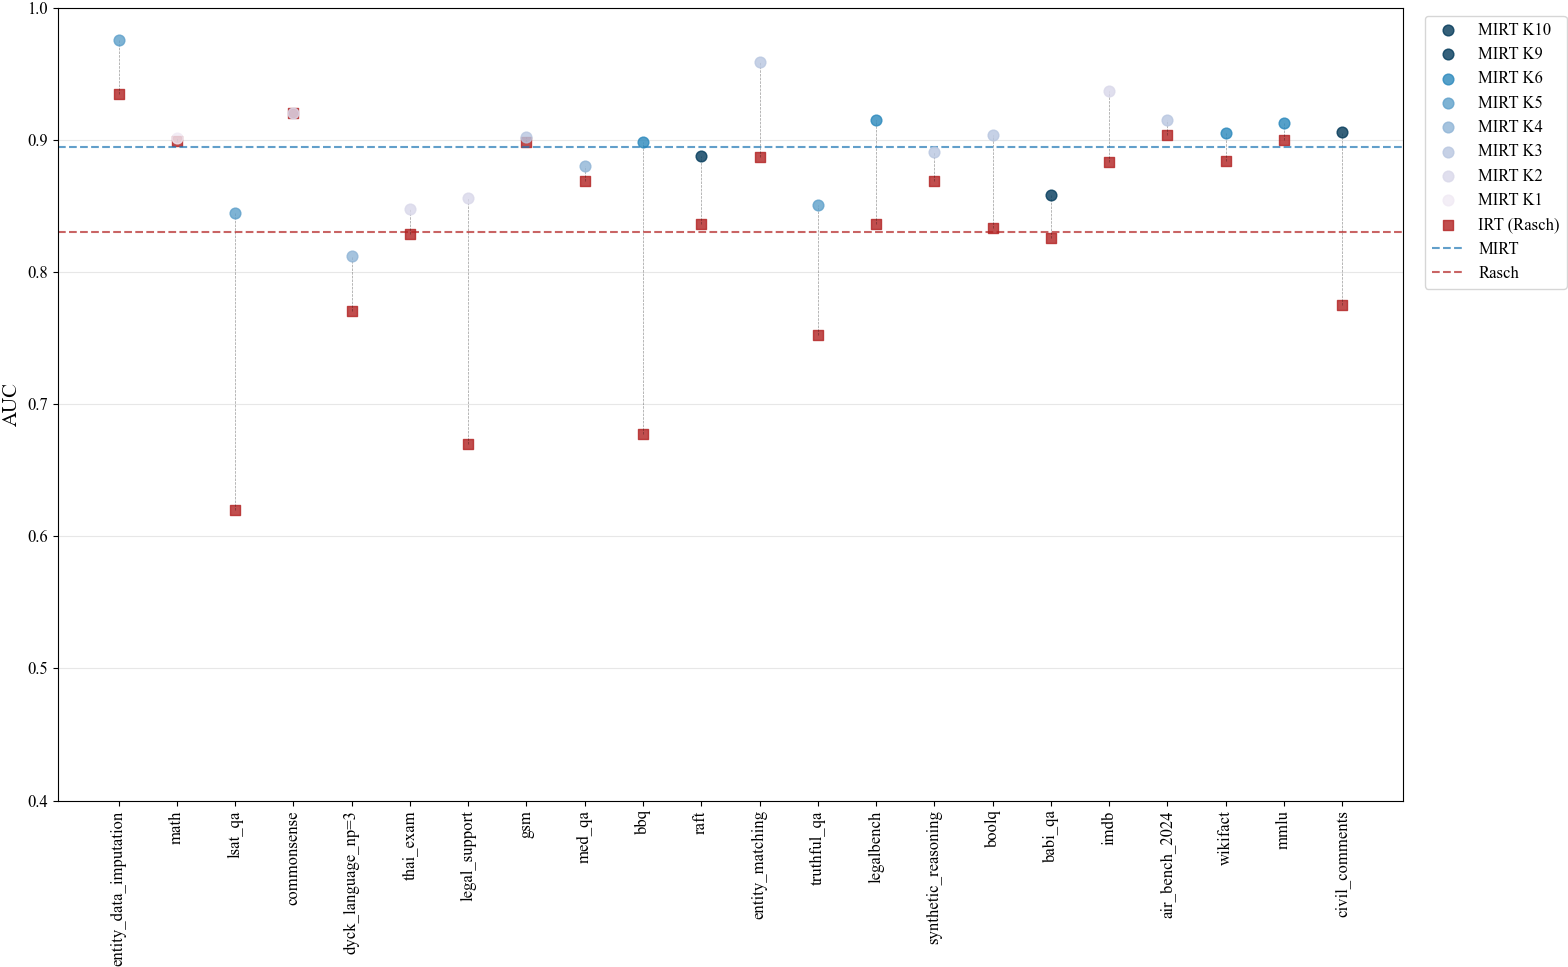

In [93]:
# Create simplified plot showing only IRT and highest MIRT AUC, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))
# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df['k_factor'].unique())

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# For each scenario, find the highest MIRT AUC across all k-factors
highest_mirt_data = []
for scenario in scenarios:
    df_scenario = df[df['scenario'] == scenario]
    if len(df_scenario) > 0:
        # Find the row with the highest MIRT AUC for this scenario
        max_mirt_row = df_scenario.loc[df_scenario['mirt'].idxmax()]
        highest_mirt_data.append({
            'scenario': scenario,
            'mirt': max_mirt_row['mirt'],
            'k_factor': max_mirt_row['k_factor'],
            'irt': max_mirt_row['irt'],
            'size': max_mirt_row['size']
        })

# Convert to DataFrame for easier handling
highest_mirt_df = pd.DataFrame(highest_mirt_data)

# Create the same color map as before
colors = plt.get_cmap('PuBu')
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Get unique k-factors that actually appear as highest performers
highest_k_factors = sorted(highest_mirt_df['k_factor'].unique())

# Plot the highest MIRT points grouped by k-factor for legend purposes
plotted_k_factors = set()
for k_factor in reversed(highest_k_factors):
    # Get all scenarios where this k-factor is the highest performer
    k_data = highest_mirt_df[highest_mirt_df['k_factor'] == k_factor]
    
    x_positions = [x_pos[scenario] for scenario in k_data['scenario']]
    
    # Plot points for this k-factor
    ax.scatter(x_positions, k_data['mirt'], 
              color=color_map[k_factor], s=60, 
              label=f'MIRT K{k_factor}', 
              marker='o', alpha=0.8, zorder=3)
    
    plotted_k_factors.add(k_factor)

# Plot IRT (Rasch) points - same as before
df_irt = df.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between IRT and highest MIRT for each scenario
for _, row in highest_mirt_df.iterrows():
    x = x_pos[row['scenario']]
    
    # Draw line between IRT and highest MIRT value
    ax.plot([x, x], [row['irt'], row['mirt']], 'k--', linewidth=0.5, alpha=0.4)

# Calculate and plot average lines
mirt_avg = highest_mirt_df['mirt'].mean()
irt_avg = df_irt['irt'].mean()

# Add horizontal lines for averages
ax.axhline(y=mirt_avg, color='C0', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'MIRT', zorder=2)
ax.axhline(y=irt_avg, color='firebrick', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'Rasch', zorder=2)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1052/799792649.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


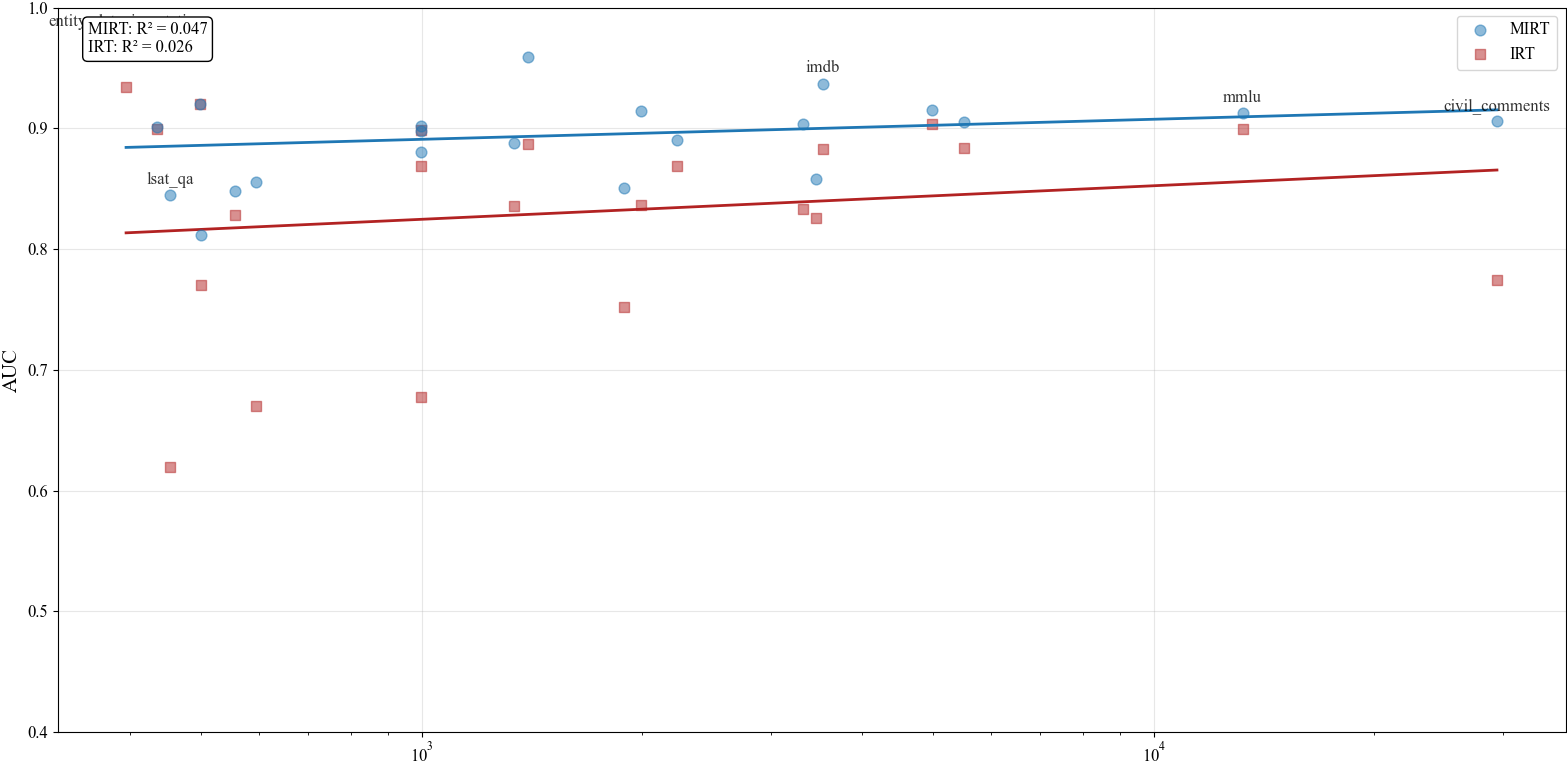

In [94]:
# Create scatter plot: Dataset Size vs AUC Performance
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(16, 8))

# Prepare data for the size vs AUC plot
# Get highest MIRT performance for each scenario
size_auc_data = []
for scenario in df['scenario'].unique():
    df_scenario = df[df['scenario'] == scenario]
    if len(df_scenario) > 0:
        # Get the highest MIRT AUC for this scenario
        max_mirt_row = df_scenario.loc[df_scenario['mirt'].idxmax()]
        
        size_auc_data.append({
            'scenario': scenario,
            'size': max_mirt_row['size'],
            'mirt_highest': max_mirt_row['mirt'],
            'irt': max_mirt_row['irt']
        })

# Convert to DataFrame
size_auc_df = pd.DataFrame(size_auc_data)

# Sort by size for cleaner plotting
size_auc_df = size_auc_df.sort_values('size')

# Plot scatter points
ax.scatter(size_auc_df['size'], size_auc_df['mirt_highest'], 
          color='C0', s=60, alpha=0.5, label='MIRT', zorder=3)
ax.scatter(size_auc_df['size'], size_auc_df['irt'], marker='s',
          color='firebrick', s=60, alpha=0.5, label='IRT', zorder=2)

# Fit and plot trend lines
# MIRT trend line
mirt_slope, mirt_intercept, mirt_r, _, _ = stats.linregress(np.log10(size_auc_df['size']), size_auc_df['mirt_highest'])
x_trend = np.logspace(np.log10(size_auc_df['size'].min()), np.log10(size_auc_df['size'].max()), 100)
mirt_trend = mirt_slope * np.log10(x_trend) + mirt_intercept
ax.plot(x_trend, mirt_trend, color='C0', linestyle='-', linewidth=2, alpha=1, zorder=2)

# IRT trend line
irt_slope, irt_intercept, irt_r, _, _ = stats.linregress(np.log10(size_auc_df['size']), size_auc_df['irt'])
irt_trend = irt_slope * np.log10(x_trend) + irt_intercept
ax.plot(x_trend, irt_trend, color='firebrick', linestyle='-', linewidth=2, alpha=1, zorder=2)

# Add scenario labels for key points
for _, row in size_auc_df.iterrows():
	# Label only some scenarios to avoid clutter
	if row['scenario'] in ['civil_comments', 'entity_data_imputation', 'lsat_qa', 'mmlu', 'imdb']:
		ax.annotate(row['scenario'], 
				   (row['size'], row['mirt_highest']), 
				   xytext=(0, 8), textcoords='offset points', 
				   fontsize=12, alpha=0.8, ha='center')

# Customize the plot
ax.set_xscale('log')
ax.set_ylabel('AUC')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.0)

# Add correlation info
ax.text(0.02, 0.98, f'MIRT: R² = {mirt_r**2:.3f}\nIRT: R² = {irt_r**2:.3f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=1))

plt.tight_layout()
plt.show()

# Interpretability check
`lsat_qa` with k=2

In [ ]:
# from load_params import load_and_rotate
# import pandas as pd
# import numpy as np
# import sys
# sys.path.append('..') 
# import style
# # Concatenate math and gsm outputs for theta, a, b
# theta, a, b = load_and_rotate('../result/mirt-fitting/mirt_model_k2_legalbench.pt', rotation=None)

# resmat = pd.read_pickle('../data/resmat.pkl')

# conv = ['legalbench']

# conv_mask = resmat.loc[:, resmat.columns.get_level_values("scenario").isin(conv)]

# conv_questions = conv_mask.columns.get_level_values('input.text').tolist()


# theta_df = pd.DataFrame(theta, columns=[f'Factor_{i+1}' for i in range(theta.shape[1])], index=resmat.index)
# a_df = pd.DataFrame(a, columns=[f'Factor_{i+1}' for i in range(a.shape[1])])
# a_df['question'] = conv_questions

# models_answered = conv_mask.dropna(how='all').index.tolist()
# accuracy = (conv_mask.sum(axis=1) / conv_mask.notnull().sum(axis=1)).loc[models_answered]
# theta_irt = pd.read_csv('../result/irt-fitting/calibration_result_theta_legalbench.csv')
# theta_df = theta_df.loc[models_answered]
# theta_df['accuracy'] = accuracy
# theta_df['irt'] = theta_irt.values

# from calculate_p import compute_eap_map_sd

# # Example shapes
# Y = conv_mask.dropna(how='all').values
# A = a_df.select_dtypes(include=[np.number]).values

# eap, map_, sd = compute_eap_map_sd(Y, A, b, n_points=21)

In [7]:
from load_params import load_and_rotate
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.append('..') 
import style
# Concatenate math and gsm outputs for theta, a, b
theta, a, b = load_and_rotate('../result/mirt-fitting/mirt_model_k2_legalbench.pt', rotation=None)

resmat = pd.read_pickle('../data/resmat.pkl')

conv = ['legalbench']

conv_mask = resmat.loc[:, resmat.columns.get_level_values("scenario").isin(conv)]

conv_questions = conv_mask.columns.get_level_values('input.text').tolist()

answers_path = Path('../data/legalbench/legalbench_result.pkl')
if not answers_path.exists():
    raise FileNotFoundError(f'Expected answer key at {answers_path} was not found.')
answer_df = pd.read_pickle(answers_path)
answer_frame = answer_df.loc['answer'].rename('answer').reset_index()
type_frame = answer_df.loc['type'].rename('type').reset_index()
answer_frame['scenario'] = answer_frame['scenario'].astype(str).str.lower()
type_frame['scenario'] = type_frame['scenario'].astype(str).str.lower()
merged_answers = answer_frame.merge(
    type_frame[['scenario', 'input.text', 'type']],
    on=['scenario', 'input.text'],
    how='left'
 )
answer_map = merged_answers[merged_answers['scenario'] == 'legalbench'].set_index('input.text')[['answer', 'type']]
answers_aligned = answer_map.reindex(conv_questions)
if answers_aligned['answer'].isna().any() or answers_aligned['type'].isna().any():
    missing_answers = answers_aligned[answers_aligned['answer'].isna()].index.tolist()
    missing_types = answers_aligned[answers_aligned['type'].isna()].index.tolist()
    raise ValueError(
        'Missing answers or types for prompts. '
        f'Missing answers: {missing_answers[:5]} | Missing types: {missing_types[:5]}'
    )

theta_df = pd.DataFrame(theta, columns=[f'Factor_{i+1}' for i in range(theta.shape[1])], index=resmat.index)
a_df = pd.DataFrame(a, columns=[f'Factor_{i+1}' for i in range(a.shape[1])])
a_df['question'] = conv_questions
a_df['answer'] = answers_aligned['answer'].values
a_df['type'] = answers_aligned['type'].values

models_answered = conv_mask.dropna(how='all').index.tolist()
accuracy = (conv_mask.sum(axis=1) / conv_mask.notnull().sum(axis=1)).loc[models_answered]
theta_irt = pd.read_csv('../result/irt-fitting/calibration_result_theta_legalbench.csv')
theta_df = theta_df.loc[models_answered]
theta_df['accuracy'] = accuracy
theta_df['irt'] = theta_irt.values

from calculate_p import compute_eap_map_sd

# Example shapes
Y = conv_mask.dropna(how='all').values
A = a_df.select_dtypes(include=[np.number]).values

eap, map_, sd = compute_eap_map_sd(Y, A, b, n_points=21)

--- Loading from Cache ---
Loaded cached theta shape: (183, 2)
Loaded cached a shape: (1997, 2)
Loaded cached b shape: (1997,)



In [43]:
# get all index entries that start with "meta" from theta_df
meta_idx = [idx for idx in theta_df.index if str(idx).startswith('meta')]
meta_idx, len(meta_idx)

(['meta/llama-2-13b',
  'meta/llama-3.2-11b-vision-instruct-turbo',
  'meta/llama-3.1-8b-instruct-turbo',
  'meta/llama-65b',
  'meta/llama-2-7b',
  'meta/llama-2-70b',
  'meta/llama-3-8b',
  'meta/llama-3.1-70b-instruct-turbo',
  'meta/llama-3.1-405b-instruct-turbo',
  'meta/llama-3-70b',
  'meta/llama-3.3-70b-instruct-turbo',
  'meta/llama-3.2-90b-vision-instruct-turbo'],
 12)

In [13]:
import numpy as np
from factor_analyzer.rotator import Rotator
# varimax, oblimax, quartimax, equamax, geomin_ort, promax, oblimin, quartimin, geomin_obl
# promax, oblimin, quartimin, geomin_obl, oblimax
method = "oblimax"
rotator = Rotator(method=method)
A_rot = rotator.fit_transform(A)

# Rotation matrix R can be retrieved
R = rotator.rotation_

# Apply the same rotation to person scores
eap_rot = eap @ R
map_rot = map_ @ R

a_df['Factor_1'] = A_rot[:,0]
a_df['Factor_2'] = A_rot[:,1]
export_cols = ['Factor_1', 'Factor_2', 'question', 'answer', 'type']
available_cols = [col for col in export_cols if col in a_df.columns]
a_export = a_df[available_cols]
a_export.to_csv(f'../output/conv_item_loadings_rotated_{method}.csv', index=False)
a_export.sort_values(by='Factor_1', ascending=False).head(250).to_csv('../output/conv_item_loadings_rotated_sorted_f1.csv', index=False)
a_export.sort_values(by='Factor_1', ascending=True).head(250).to_csv('../output/conv_item_loadings_rotated_sorted_f1_asc.csv', index=False)
a_export.sort_values(by='Factor_2', ascending=False).head(250).to_csv('../output/conv_item_loadings_rotated_sorted_f2.csv', index=False)
a_export.sort_values(by='Factor_2', ascending=True).head(250).to_csv('../output/conv_item_loadings_rotated_sorted_f2_asc.csv', index=False)

theta_score_df = pd.DataFrame(eap_rot, columns=[f'f{i+1}' for i in range(eap_rot.shape[1])], index=theta_df.index)
theta_score_df['accuracy'] = accuracy
theta_score_df['irt'] = theta_irt.values
theta_score_df.dropna(how='any', inplace=True)
theta_score_df = theta_score_df.round(6)

In [97]:
# scatter plot with highlighted labels
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 1. Create a Sample theta_df DataFrame ---
# # (Replace this with your actual theta_df)
# # We'll create a sample with more points than just the ones to be labeled.
# np.random.seed(42)
# model_names = [
#     'google/gemini-1.5-pro-001', 'openai/gpt-4-turbo-2024-04-09',
#     'amazon/nova-micro-v1:0', 'cohere/command-light',
#     'anthropic/claude-3-opus-20240229', 'mistralai/mistral-large-latest',
#     'meta-llama/llama-3-70b-instruct'
# ]

# # --- 2. Define the labels you want to plot ---
# labels_to_plot = [
#     'google/gemini-1.5-pro-001',
#     'openai/gpt-4-turbo-2024-04-09',
#     'amazon/nova-micro-v1:0',
#     'cohere/command-light'
# ]

# # --- 3. Create the plot ---
# plt.figure(figsize=(10, 8))

# # Plot all points from the DataFrame as a background
# plt.scatter(theta_score_df['f1'], theta_score_df['f2'], c='lightblue', label='All Models')

# # Highlight and label the specific points
# for label in labels_to_plot:
#     if label in theta_score_df.index:
#         # Get the coordinates for the label
#         x = theta_score_df.loc[label, 'f1']
#         y = theta_score_df.loc[label, 'f2']
        
#         # Plot a more prominent marker for the specific model
#         plt.scatter(x, y, c='red', s=100) # s is marker size
        
#         # Add the text label slightly offset from the point
#         plt.text(x + 0.05, y + 0.05, label, fontsize=9, color='darkred')

# # --- 4. Formatting ---
# plt.title('Scatter Plot of Model Abilities (Theta)')
# plt.xlabel('Dimension 1 (θ₁)')
# plt.ylabel('Dimension 2 (θ₂)')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
# plt.xlim(-4, 4)
# plt.ylim(-4, 4)
# plt.legend()
# plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1052/3184094662.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


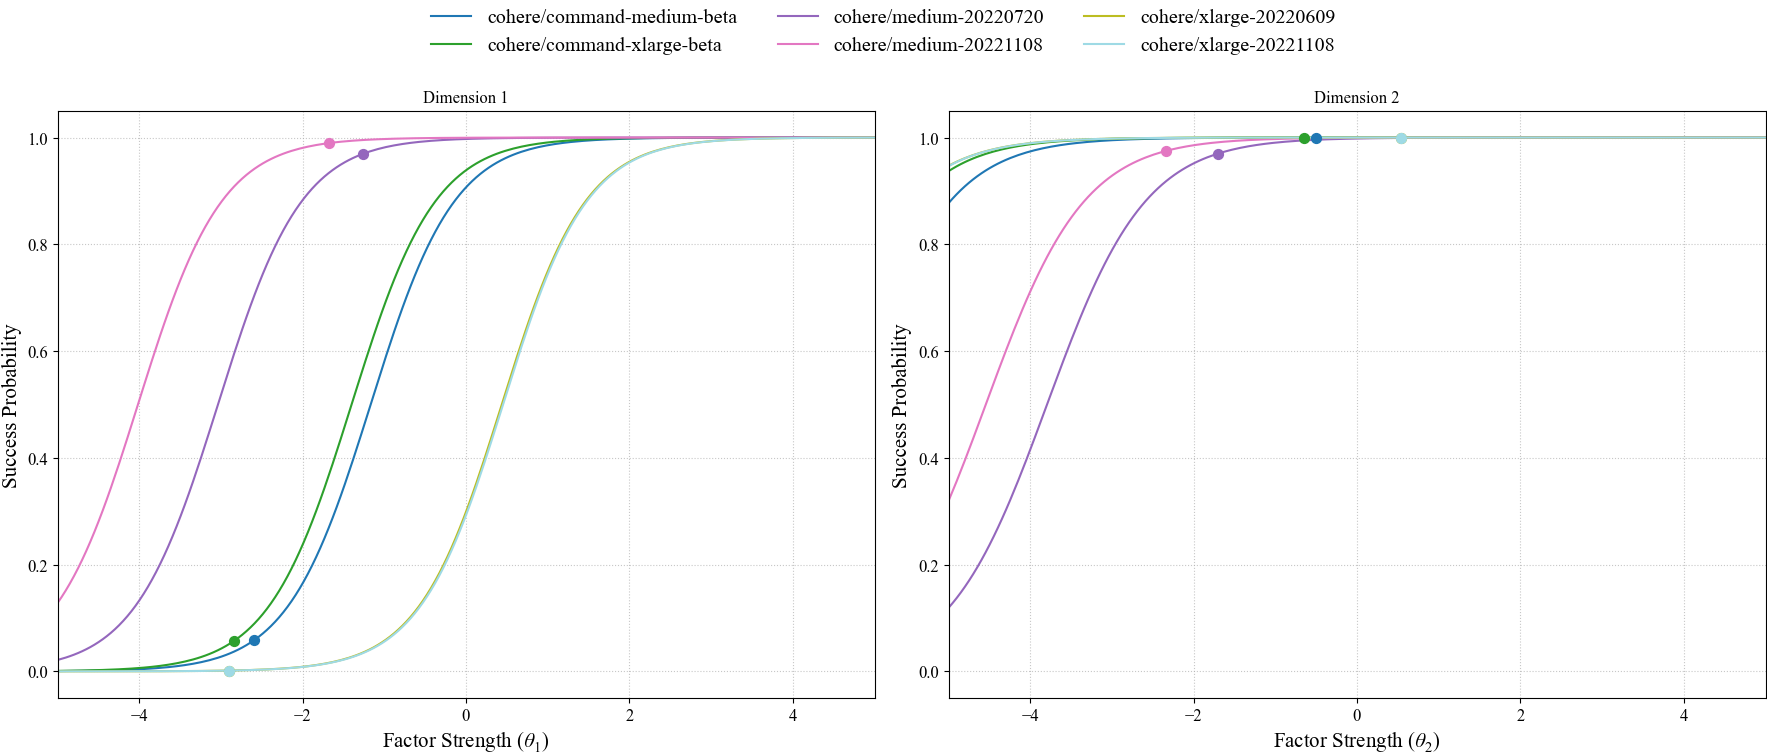

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

def plot_conditional_iccs_for_models(theta_df, a_df, b_df, labels_to_plot):
    """
    Plots Conditional Item Characteristic Curves for a list of models.
    Each model gets its own curve on an ability (theta) x-axis.
    """
    # 1. Find the most representative item for each dimension
    dim1_item_idx = (a_df.iloc[:, 0] - a_df.iloc[:, 1]).idxmax()
    dim2_item_idx = (a_df.iloc[:, 1] - a_df.iloc[:, 0]).idxmax()

    a1_params = a_df.loc[dim1_item_idx]
    b1_param = b_df.loc[dim1_item_idx, 'Difficulty']
    
    a2_params = a_df.loc[dim2_item_idx]
    b2_param = b_df.loc[dim2_item_idx, 'Difficulty']

    # 2. Set up the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Use a color cycle for the models
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels_to_plot)))
    ax1.set_prop_cycle(cycler('color', colors))
    ax2.set_prop_cycle(cycler('color', colors))

    # --- Plot for Dimension 1 ---
    theta1_range = np.linspace(-5, 5, 200) 
    for label in labels_to_plot:
        if label in theta_df.index:
            theta_model = theta_df.loc[label]
            theta2_fixed = theta_model.iloc[1]

            prob_curve = 1 / (1 + np.exp(-(a1_params.values[0] * theta1_range + a1_params.values[1] * theta2_fixed - b1_param)))
            ax1.plot(theta1_range, prob_curve, label=label)

            actual_prob = 1 / (1 + np.exp(-(np.dot(a1_params.values, theta_model.values) - b1_param)))
            ax1.scatter(theta_model.iloc[0], actual_prob, s=50, zorder=5, color=ax1.get_lines()[-1].get_color())

    ax1.set_title('Dimension 1')
    ax1.set_xlabel(r'Factor Strength ($\theta_1$)')
    ax1.set_ylabel('Success Probability')
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_xlim(-5, 5)
    ax1.grid(True, linestyle=':', alpha=0.7)

    # --- Plot for Dimension 2 ---
    theta2_range = np.linspace(-5, 5, 200)
    for label in labels_to_plot:
        if label in theta_df.index:
            theta_model = theta_df.loc[label]
            theta1_fixed = theta_model.iloc[0]

            prob_curve = 1 / (1 + np.exp(-(a2_params.values[0] * theta1_fixed + a2_params.values[1] * theta2_range - b2_param)))
            ax2.plot(theta2_range, prob_curve, label=label)

            actual_prob = 1 / (1 + np.exp(-(np.dot(a2_params.values, theta_model.values) - b2_param)))
            ax2.scatter(theta_model.iloc[1], actual_prob, s=50, zorder=5, color=ax2.get_lines()[-1].get_color())
            
    ax2.set_title('Dimension 2')
    ax2.set_xlabel(r'Factor Strength ($\theta_2$)')
    ax2.set_ylabel('Success Probability')
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_xlim(-5, 5)
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    # --- Legend and Layout Adjustment (Updated based on your reference) ---
    handles, labels = ax1.get_legend_handles_labels()

    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize='large', frameon=False)

    # REPLACED: Use tight_layout() to automatically adjust the subplot positions to make room for the legend.
    plt.tight_layout()

    plt.show()
# --- Your Calling Code ---
 
labels_to_plot = [
    'cohere/command-medium-beta',
    'cohere/command-xlarge-beta',
    'cohere/medium-20220720',
    'cohere/medium-20221108',
    'cohere/xlarge-20220609',
    'cohere/xlarge-20221108',
]

# Ensure your real DataFrames are 2D and have matching indices
a_df_2d = a_df.iloc[:, :2]
theta_df_2d = theta_df.iloc[:, :2]
a_df_2d.index = conv_questions
b_df = pd.DataFrame(b, columns=['Difficulty'], index=conv_questions)

# Call the function with your actual MIRT results
plot_conditional_iccs_for_models(theta_df_2d, a_df_2d, b_df, labels_to_plot)

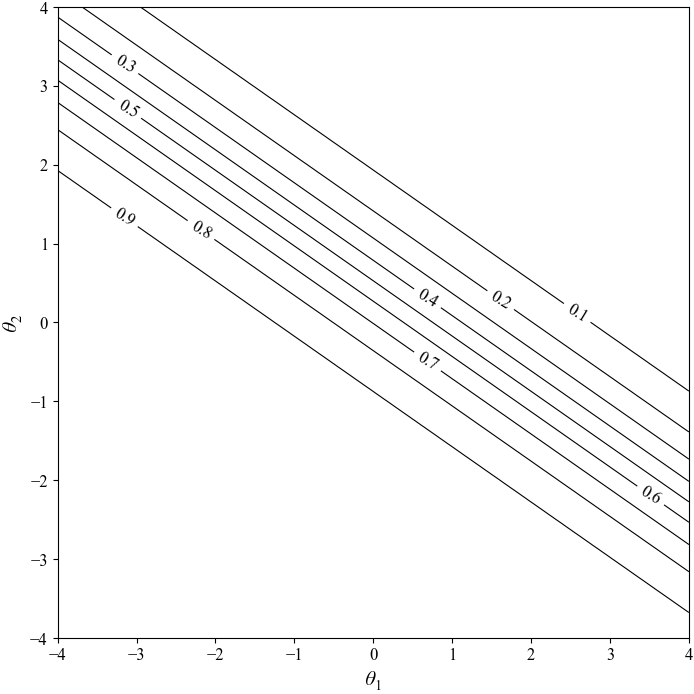

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_item_contour(item_name, a_df, b_df):
    """
    Generates a 2D Item Characteristic Contour plot in black and white for a single item.
    """
    if item_name not in a_df.index or item_name not in b_df.index:
        print(f"Error: Item '{item_name}' not found in a_df or b_df.")
        return

    # 1. Get parameters for the selected item
    a_params = a_df.loc[item_name].values
    b_param = b_df.loc[item_name, 'Difficulty']

    # 2. Create a grid of theta (ability) values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)

    # 3. Calculate the probability of a correct response across the grid
    prob_surface = 1 / (1 + np.exp(-(a_params[0] * theta1_grid + a_params[1] * theta2_grid - b_param)))

    # 4. Create the 2D contour plot
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # CHANGED: Contour lines are now black to be visible on a white background
    contour_lines = ax.contour(theta1_grid, theta2_grid, prob_surface, levels=np.arange(0.1, 1.0, 0.1), colors='black', linewidths=0.8)
    ax.clabel(contour_lines, inline=True, fontsize=12, fmt='%1.1f')

    # 5. Formatting
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    # ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_aspect('equal')
    
    plt.show()

# Choose an item to plot from your a_df's index
item_to_plot = a_df_2d.index[4] 

# Call the function
plot_item_contour(item_to_plot, a_df_2d, b_df)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1052/3964282607.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


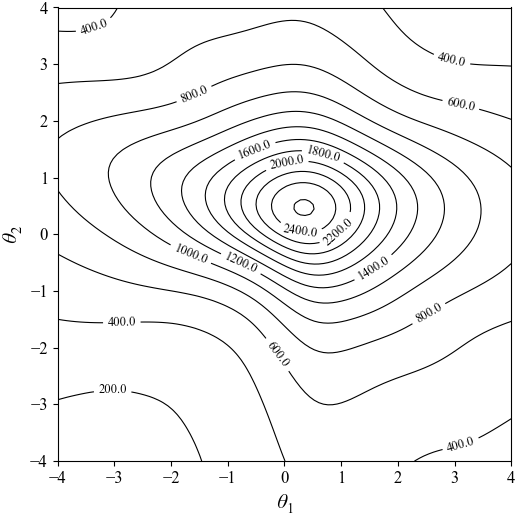

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_test_information(ax, a_df, b_df):
    """
    Calculates and plots the Test Information Contour Map on a given axis (no rotation).

    Args:
        ax (matplotlib.axes.Axes): The subplot axis to draw on.
        a_df (pd.DataFrame): DataFrame of item discriminations.
        b_df (pd.DataFrame): DataFrame of item difficulties.
    """
    # 1. Create a grid of theta values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)
    total_information_surface = np.zeros_like(theta1_grid)

    # 2. Calculate total information using original parameters
    for i in range(len(a_df)):
        a_params = a_df.iloc[i].values
        b_param = b_df.iloc[i]['Difficulty']

        prob_surface = 1 / (1 + np.exp(-(a_params[0] * theta1_grid + a_params[1] * theta2_grid - b_param)))
        item_info_surface = np.sum(np.square(a_params)) * prob_surface * (1 - prob_surface)
        total_information_surface += item_info_surface

    # 3. Plot the contour on the provided axis
    contour_lines = ax.contour(theta1_grid, theta2_grid, total_information_surface, levels=15, colors='black', linewidths=0.8)
    ax.clabel(contour_lines, inline=True, fontsize=9, fmt='%1.1f')
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_aspect('equal')

# Set up the figure with a single subplot
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))

# Plot for 0 degrees (no rotation)
plot_test_information(ax, a_df_2d, b_df)

plt.tight_layout()
plt.show()

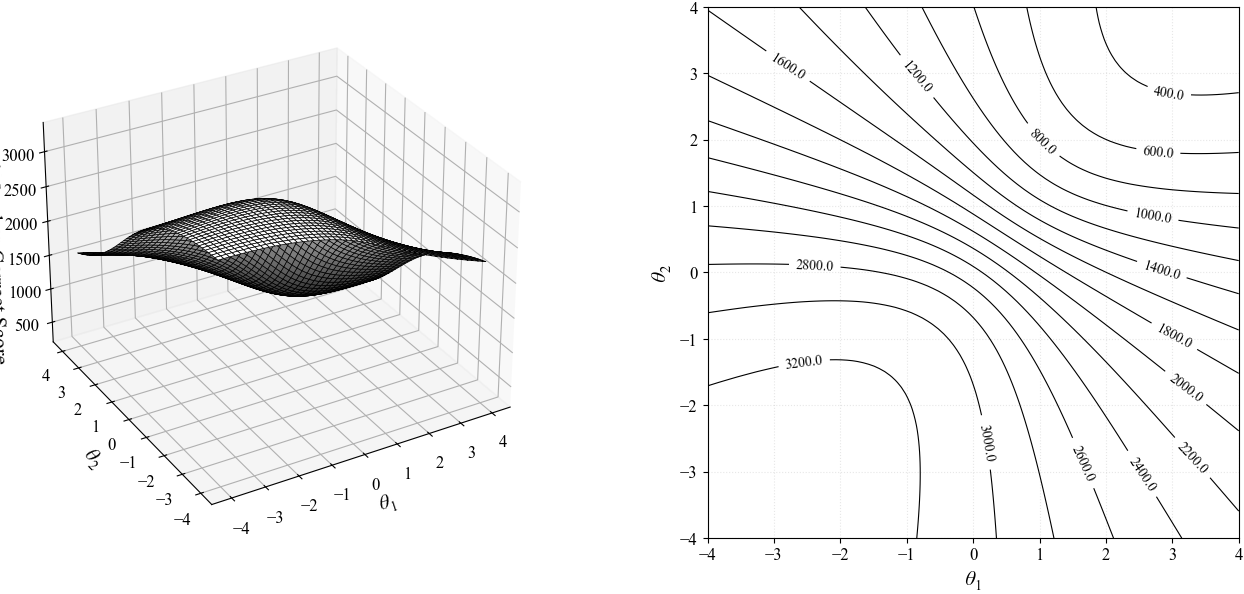

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_test_characteristic_pair(a_df, b_df):
    """
    Calculates and plots the Test Characteristic Surface and its corresponding
    2D contour map.

    Args:
        a_df (pd.DataFrame): DataFrame of item discriminations for the entire test.
        b_df (pd.DataFrame): DataFrame of item difficulties for the entire test.
    """
    # 1. Create a grid of theta (ability) values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)

    # 2. Calculate the Expected Number-Correct Score across the grid
    # This is the sum of probabilities for all items.
    expected_score_surface = np.zeros_like(theta1_grid)

    for i in range(len(a_df)):
        a_params = a_df.iloc[i].values
        b_param = b_df.iloc[i]['Difficulty']
        
        # Calculate probability for this item and add it to the total expected score
        prob_surface = 1 / (1 + np.exp(-(a_params[0] * theta1_grid + a_params[1] * theta2_grid - b_param)))
        expected_score_surface += prob_surface

    # 3. Set up the figure with two subplots
    fig = plt.figure(figsize=(14, 6))

    # --- Subplot 1: 3D Surface ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    
    ax1.plot_surface(theta1_grid, theta2_grid, expected_score_surface,
                     cmap='gray', linewidth=0.5, edgecolor='black')
    
    ax1.set_xlabel(r'$\theta_1$')
    ax1.set_ylabel(r'$\theta_2$')
    ax1.set_zlabel('Expected Number-Correct Score')
    ax1.view_init(elev=30, azim=-120)

    # --- Subplot 2: 2D Contour Plot ---
    ax2 = fig.add_subplot(1, 2, 2)

    contour_lines = ax2.contour(theta1_grid, theta2_grid, expected_score_surface, levels=15, colors='black', linewidths=0.8)
    ax2.clabel(contour_lines, inline=True, fontsize=10, fmt='%1.1f')

    ax2.set_xlabel(r'$\theta_1$')
    ax2.set_ylabel(r'$\theta_2$')
    ax2.grid(True, linestyle=':', alpha=0.3)
    ax2.set_aspect('equal')
    plt.show()

# Call the function
plot_test_characteristic_pair(a_df_2d, b_df)

# Discriminant Validity

In [8]:
from load_params import load_and_rotate
import pandas as pd
import sys
sys.path.append('..') 
import style
# Concatenate math and gsm outputs for theta, a, b
theta, a, b = load_and_rotate('../result/mirt-fitting/mirt_model_k2_imdb.pt', rotation=None)

resmat = pd.read_pickle('../data/resmat.pkl')

conv = ['imdb']

conv_mask = resmat.loc[:, resmat.columns.get_level_values("scenario").isin(conv)]

conv_questions = conv_mask.columns.get_level_values('input.text').tolist()


theta_df = pd.DataFrame(theta, columns=[f'Factor_{i+1}' for i in range(theta.shape[1])], index=resmat.index)
a_df = pd.DataFrame(a, columns=[f'Factor_{i+1}' for i in range(a.shape[1])])
a_df['question'] = conv_questions

models_answered = conv_mask.dropna(how='all').index.tolist()
accuracy = (conv_mask.sum(axis=1) / conv_mask.notnull().sum(axis=1)).loc[models_answered]
theta_irt = pd.read_csv('../result/irt-fitting/calibration_result_theta_imdb.csv')
theta_df = theta_df.loc[models_answered]
theta_df['accuracy'] = accuracy
theta_df['irt'] = theta_irt.values

--- Loading from Cache ---
Loaded cached theta shape: (183, 2)
Loaded cached a shape: (3530, 2)
Loaded cached b shape: (3530,)



In [9]:
import numpy as np
from factor_analyzer.rotator import Rotator
from calculate_p import compute_eap_map_sd

# Example shapes
Y = conv_mask.dropna(how='all').values
A = a_df.select_dtypes(include=[np.number]).values

eap, map_, sd = compute_eap_map_sd(Y, A, b, n_points=21)

rotator = Rotator(method="geomin_obl")   # or "oblimin"
A_rot = rotator.fit_transform(A)

# Rotation matrix R can be retrieved
R = rotator.rotation_

# Apply the same rotation to person scores
eap_rot = eap @ R
map_rot = map_ @ R

a_df['Factor_1'] = A_rot[:,0]
a_df['Factor_2'] = A_rot[:,1]

theta_score_df = pd.DataFrame(eap_rot, columns=[f'f{i+1}' for i in range(eap_rot.shape[1])], index=theta_df.index)
theta_score_df['accuracy'] = accuracy
theta_score_df['irt'] = theta_irt.values
theta_score_df.dropna(how='all', inplace=True)

In [10]:
import pandas as pd

model_spec = pd.read_csv('../data/model_specs.csv')
model_spec.dropna(subset=['size'], inplace=True)
model_spec.sort_values(by='size', ascending=False, inplace=True)
model_spec

,code,name,size,pretrain,flops
42,microsoft/TNLGv2_530B,TNLG v2 (530B),530.00,0.27,143.1
115,snowflake/snowflake-arctic-instruct,Arctic Instruct,480.00,0.40,768.0
163,meta/llama-3.1-405b-instruct-turbo,Llama 3.1 Instruct Turbo (405B),405.00,15.00,36450.0
50,ai21/j1-jumbo,J1-Jumbo v1 (178B),178.00,0.30,53.4
52,ai21/j2-jumbo,Jurassic-2 Jumbo (178B),178.00,1.20,213.6
...,...,...,...,...,...
63,openai/babbage,babbage (1.3B),1.30,NaN,NaN
89,openai/text-ada-001,text-ada-001,1.20,NaN,NaN
2,eleutherai/pythia-1b-v0,Pythia (1B),1.00,0.30,1.8
71,cohere/small-20220720,Cohere small v20220720 (410M),0.41,NaN,NaN


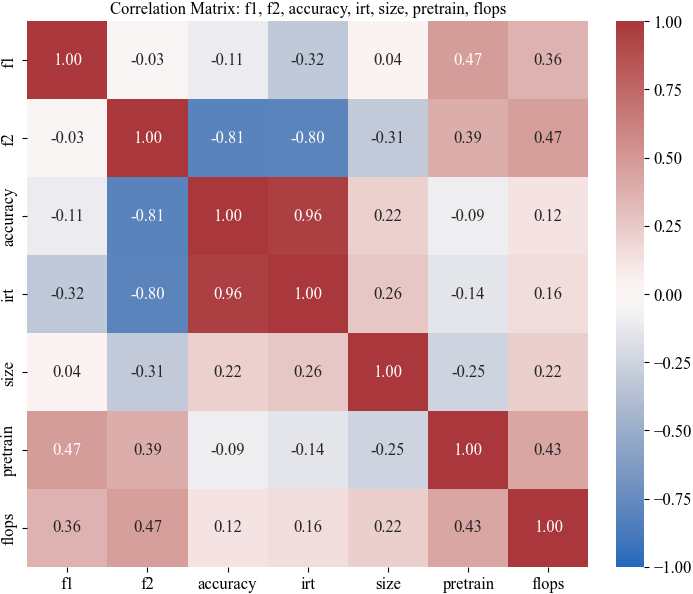

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Join model specs
model_score_df = theta_score_df.join(model_spec.set_index("code"), how="left")

# Select relevant columns for correlation
corr_cols = ['f1', 'f2', 'accuracy', 'irt', 'size', 'pretrain', 'flops']
corr_df = model_score_df[corr_cols].copy()

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix: f1, f2, accuracy, irt, size, pretrain, flops")
# Use constrained_layout to avoid RuntimeError with colorbar and tight_layout
fig.set_constrained_layout(True)
plt.show()

# Verification of F1 and F2

## F2: Reasoning Focus Axis

- A high score (+) on this axis indicates a "Specialized Abstract" style. This is the behavior of excelling at structured, objective analysis.

- A low score (-) on this axis indicates a "General-Purpose" style. This is the behavior of excelling at flexible, context-bound information extraction.

In [15]:
selected = resmat.loc[model_score_df.index, :].dropna(how='all')
selected_columns = selected.columns.get_level_values('scenario').unique().tolist()

In [16]:
import pandas as pd

# 1. Define the complete list of scenarios
SCENARIOS = [
    'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact', 'bbq',
    'thai_exam', 'dyck_language_np=3', 'legal_support', 'civil_comments', 'legalbench',
    'raft', 'air_bench_2024', 'math', 'med_qa', 'gsm', 'boolq', 'mmlu',
    'entity_matching', 'entity_data_imputation', 'commonsense', 'imdb'
]

# 2. Use a dictionary comprehension to calculate the sum for each scenario.
# The keys of the dictionary will become the column names.
sum_data = {
    scenario: resmat.loc[
        model_score_df.index,
        resmat.columns.get_level_values("scenario") == scenario
    ].sum(axis=1)
    for scenario in SCENARIOS
}

# 3. Create the final DataFrame from the dictionary
result_sum = pd.DataFrame(sum_data)

In [17]:
result_sum

,lsat_qa,truthful_qa,synthetic_reasoning,babi_qa,wikifact,bbq,thai_exam,dyck_language_np=3,legal_support,civil_comments,...,air_bench_2024,math,med_qa,gsm,boolq,mmlu,entity_matching,entity_data_imputation,commonsense,imdb
request.model,,,,,,,,,,,,,,,,,,,,,
together/t0pp,97.0,729.0,0.0,0.0,64.0,495.0,0.0,8.0,364.0,7500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,91.0
together/opt-66b,86.0,391.0,527.0,1025.0,1412.0,381.0,0.0,218.0,295.0,5017.0,...,0.0,0.0,0.0,0.0,2502.0,0.0,1038.0,298.0,0.0,613.0
together/opt-175b,83.0,431.0,589.0,1026.0,1511.0,351.0,0.0,225.0,306.0,4764.0,...,0.0,0.0,0.0,0.0,2504.0,0.0,1121.0,298.0,0.0,642.0
cohere/large-20220720,80.0,297.0,344.0,835.0,2126.0,318.0,0.0,183.0,308.0,6460.0,...,0.0,0.0,0.0,0.0,2328.0,0.0,639.0,302.0,0.0,637.0
together/gpt-neox-20b,94.0,446.0,452.0,1129.0,1457.0,316.0,0.0,373.0,291.0,6326.0,...,0.0,0.0,0.0,0.0,2164.0,0.0,1186.0,296.0,0.0,644.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
together/glm,80.0,381.0,641.0,1095.0,1733.0,284.0,0.0,287.0,290.0,23751.0,...,0.0,0.0,0.0,0.0,2628.0,0.0,707.0,267.0,0.0,651.0
ai21/j2-grande,80.0,520.0,692.0,1088.0,2363.0,444.0,0.0,257.0,340.0,22972.0,...,0.0,29.0,386.0,159.0,2707.0,0.0,1195.0,349.0,306.0,3199.0
together/redpajama-incite-instruct-3b-v1,82.0,387.0,427.0,1187.0,1226.0,0.0,0.0,354.0,294.0,23689.0,...,0.0,0.0,0.0,0.0,2120.0,0.0,1187.0,313.0,0.0,2443.0


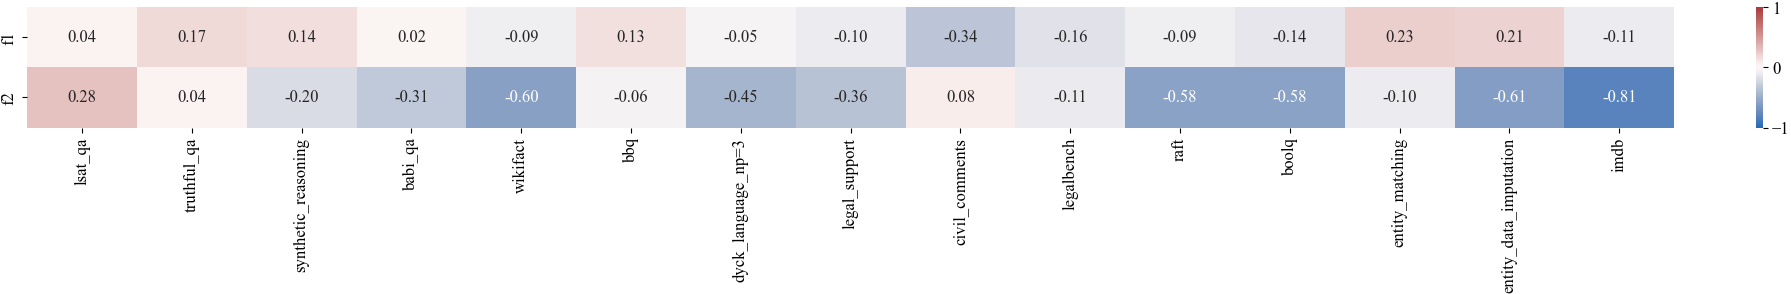

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Join model specs
conv_score_df = theta_score_df.join(result_sum, how="left")

# Select relevant columns for correlation
corr_cols = [*SCENARIOS, 'f1', 'f2']
except_cols = ['thai_exam', 'air_bench_2024', 'mmlu', 'math', 'gsm', 'commonsense', 'med_qa',
               'f1', 'f2']
corr_df = conv_score_df[corr_cols].copy()
# Compute correlation matrix
corr_matrix = corr_df.corr()
corr_cols = [col for col in corr_cols if col not in except_cols]


corr_matrix = corr_matrix.loc[['f1', 'f2'], corr_cols]

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(18, 3))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt=".2f", ax=ax, vmin=-1, vmax=1)

fig.set_constrained_layout(True)
plt.show()

## Verify F1

In [7]:
import pandas as pd
import sys
sys.path.append('..')
from string_utils import tokenize_words

result_civil_comment = pd.read_pickle('../data/civil_comments/result_civil_comments.pkl')

negative_score = result_civil_comment.sum(axis=0)
comment_length = result_civil_comment.columns.to_series().apply(lambda text: len(tokenize_words(text)))
result_civil_comment.loc['comment_length'] = comment_length
result_civil_comment.loc['negative_score'] = negative_score

result_civil_comment.loc[['negative_score', 'comment_length'], negative_score.sort_values(ascending=False).head(10).index]

,Only a fuckin nigger would do something like this.\nQuestion: Is the passage above toxic?,the righteous alt left will eradicate fascist inbred redneck white supremacists like cockroaches. we'll hunt them down like pigs and lynch them in our town squares and cities. we'll gut them as they emerge from theri backwoods swamps. be warned white supremacist/nationalist scum. we'll kill you and burn down your homes and destory you and your familes. the righteous alt left will cut your filthy throats in your homes in fort of your children.\nquestion: is the passage above toxic?,The righteous ALT LEFT will eradicate fascist inbred redneck white supremacists like cockroaches. We will hunt them down like pigs and lynch them in our town squares and cities. We will gut them as they emerge from their backwoods swamps. Be warned white supremacist/nationalist scum. We will kill you and burn down your homes and destroy you and your families. The righteous ALT LEFT will cut your filthy throats in your homes in fort of your children.\nQuestion: Is the passage above toxic?,Fuck this ain't no female this is a crazy ass tranny that threatens and harasses the homeless threatens people on a regular picks fights with men all the time I think it's bs that she she is playing the poor women card when she has no problem picking fights with men and has harassed Jeeves the one who pushed her many times don't talk shit don't get thrown through a window pretty simple\nQuestion: Is the passage above toxic?,fuck this ain't no female this is a crazy ass tranny that threatens and harasses the homeless threatens people on a regular picks fights with men all the time i think it's bs that she he's playing the poor women card when she has no problem picking fights whith men and has harassed jeeves the one who pushed her many times don't talk shit don't get thrown through a window pretty simple\nquestion: is the passage above toxic?,Fuck this ain't no female this is a crazy ass tranny that threatens and harasses the homeless threatens people on a regular picks fights with men all the time I think it's bs that she he is playing the poor women card when she has no problem picking fights with men and has harassed Jeeves the one who pushed her many times don't talk shit don't get thrown through a window pretty simple\nQuestion: Is the passage above toxic?,When a HOMOSEXUAL that HAS SEX WITH DOGS WAS PRESIDENT LITTLE BLAK BARRY the MUSLUM DOG RAPING NIGER\nshe was DESTROYING the NATION\nHer ARMY of CANINE MEAT LOCKER MOUTH PROGRESSIVES will SOON be EXTINCT\nALONG WITH the NIGER RACE\nGOD is CALLING the SCUM HOME\nQuestion: Is the passage above toxic?,When a HOMOSEXUAL that HAS SEX WITH DOGS WAS PRESIDENT LITTLE BLAK BARRY the MUSLUM DOG RAPING NIGER\nhe was DESTROYING the NATION\nHis ARMY of CANINE MEAT LOCKER MOUTH PROGRESSIVES will SOON be EXTINCT\nALONG WITH the NIGER RACE\nGOD is CALLING the SCUM HOME\nQuestion: Is the passage above toxic?,"there's been ugly women through out history - but clinton isn't lonly ugly through and thru down to the bone - she has a vile hideous personality that's like acid to those who've to watch, listen anbd deal with her. what's so disgusting - is that she feels so entitled, owed, and expects the worls to kowtow, genuflect and kiss her ass because she's hillary clinton... while she demonstrates a penchant for a complete lack of respect for human life, the willingness to break federal laws of the usa and the world, she's a thief and a shyster, an electon fraudster and will rig and buy votes if onot outright black-mail or kill indviduals that stand in her way. what she's really owed is a federal prison orange jump suit with a date scheduled to face a firing squad.\nquestion: is the passage above toxic?","i suspect there is, in this debate, also something at play which the blogger john pavlovitz calls ""americhristianity"" [http://johnpavlovitz.com/2015/11/17/freeing-christians-from-americhristianity/]. though his piece aims at the exploitat

## Testing correlation with adjacent metrics, `civil_comments`

In [186]:
models = ['together/t0pp', 'together/opt-66b', 'together/opt-175b', 'cohere/large-20220720', 'together/gpt-neox-20b', 'writer/palmyra-x', 'together/gpt-j-6b', 'cohere/medium-20220720', 'cohere/command-medium-beta', 'openai/curie', 'together/ul2', 'openai/davinci', 'AlephAlpha/luminous-base', 'together/redpajama-incite-base-7b', 'eleutherai/pythia-6.9b', 'meta/llama-7b', 'mosaicml/mpt-instruct-30b', 'cohere/xlarge-20220609', 'meta/llama-13b', 'openai/text-curie-001', 'microsoft/TNLGv2_7B', 'together/t5-11b', 'microsoft/TNLGv2_530B', 'lmsys/vicuna-13b-v1.3', 'stanford/alpaca-7b', 'mosaicml/mpt-30b', 'ai21/j1-jumbo', 'lmsys/vicuna-7b-v1.3', 'ai21/j2-jumbo', 'meta/llama-2-13b', 'together/redpajama-incite-instruct-7b', 'ai21/j2-large', 'openai/babbage', 'together/yalm', 'AlephAlpha/luminous-supreme', 'mistralai/mistral-7b-v0.1', 'cohere/small-20220720', 'openai/gpt-3.5-turbo-0301', 'together/bloom', 'anthropic/stanford-online-all-v4-s3', 'cohere/command-xlarge-beta', 'openai/ada', 'AlephAlpha/luminous-extended', 'writer/palmyra-instruct-30', 'eleutherai/pythia-12b-v0', 'openai/gpt-3.5-turbo-0613', 'together/redpajama-incite-base-3b-v1', 'tiiuae/falcon-40b', 'openai/text-ada-001', 'meta/llama-65b', 'meta/llama-2-7b', 'cohere/xlarge-20221108', 'cohere/medium-20221108', 'meta/llama-2-70b', 'tiiuae/falcon-40b-instruct', 'openai/text-babbage-001', 'tiiuae/falcon-7b', 'ai21/j1-large', 'openai/text-davinci-002', 'ai21/j1-grande', 'openai/text-davinci-003', 'tiiuae/falcon-7b-instruct', 'together/glm', 'ai21/j2-grande', 'together/redpajama-incite-instruct-3b-v1', 'ai21/j1-grande-v2-beta', 'meta/llama-30b']

In [191]:
resmat = pd.read_pickle('../data/resmat.pkl')
target_texts = result_civil_comment.columns.tolist()
text_mask = resmat.columns.get_level_values("input.text").isin(target_texts)
resmat = resmat.loc[models, text_mask]

In [214]:
result_matrix = resmat.sum(axis=1).to_frame(name='correct')
# Align per-text negative scores to the order of resmat's columns
neg_scores = result_civil_comment.loc['negative_score']
comment_length = result_civil_comment.loc['comment_length']
col_texts = resmat.columns.get_level_values('input.text')
neg_aligned = neg_scores.reindex(col_texts).fillna(0).values

# Consider a response "correct" when it's equal to 1 (adjust if your encoding differs)
correct_mask = resmat == 1

# Sum negative scores over the texts each model got correct, then divide by number correct
neg_sum_per_model = (correct_mask * neg_aligned).sum(axis=1)
result_matrix['incorrect'] = resmat.shape[1] - result_matrix['correct']
result_matrix['comment_length'] = comment_length.mean()  # Average comment length across all texts
result_matrix['mean_negative_score'] = neg_sum_per_model / result_matrix['correct'].replace({0: np.nan})
result_matrix['neg_per_corr'] = result_matrix['mean_negative_score'] / result_matrix['correct'].replace({0: np.nan})
result_matrix['neg_per_incorr'] = result_matrix['mean_negative_score'] / result_matrix['incorrect'].replace({0: np.nan})

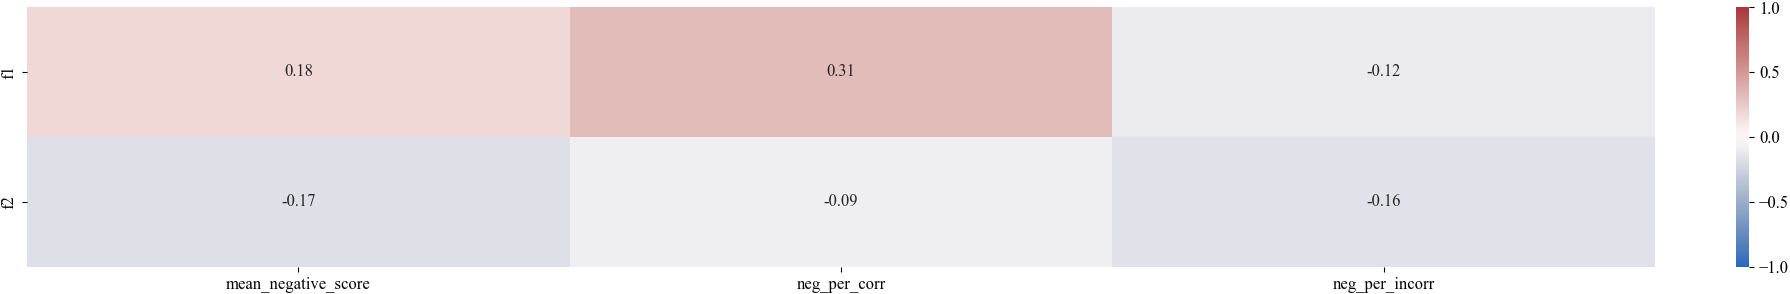

In [243]:
import seaborn as sns
import matplotlib.pyplot as plt

# Join model specs
conv_score_df = theta_score_df.join(result_matrix, how="left")

# Select relevant columns for correlation
corr_cols = ['mean_negative_score', 'neg_per_corr', 'neg_per_incorr', 'f1', 'f2']
corr_df = conv_score_df[corr_cols].copy()

# Compute correlation matrix
corr_matrix = corr_df.corr(method='pearson')
exempt_cols = ['f1', 'f2']
corr_cols = [col for col in corr_cols if col not in exempt_cols]

corr_matrix = corr_matrix.loc[['f1', 'f2'], corr_cols]

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(18, 3))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt=".2f", ax=ax, vmin=-1, vmax=1)
# Use constrained_layout to avoid RuntimeError with colorbar and tight_layout
fig.set_constrained_layout(True)
plt.show()

the model with higher `f1` is better at detecting stronger negative comments, verifying the positive pole of `f1`

- A high score (+) on this axis indicates a "Casual" style. This is the behavior of excelling at understanding simple, direct, and personal opinions.

- A low score (-) on this axis indicates an "Analytical" style. This is the behavior of excelling at parsing complex, abstract, and multi-layered arguments.